# Task 3:Sentiment Analysis using RNN, LSTM and Word2Vec Embeddings

## 1. Imports and Setup

In [3]:
import re
import time
import os
from collections import Counter

### 1.1 Data Science Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 NLP and Text Processing Libraries

In [5]:
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WordCloud = None
    WORDCLOUD_AVAILABLE = False
    print('wordcloud is not installed; word cloud visualization will be skipped.')

# Ensure NLTK is available in the current kernel environment
try:
    import nltk
except ModuleNotFoundError:
    import sys
    import subprocess
    print('nltk not found. Installing nltk in current environment...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'nltk'])
    import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

### 1.3 Deep Learning and Neural Network Libraries

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

### 1.4 Machine Learning Utilities, Reproducibility Setup, and Hardware Detection

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Training time tracker
training_times = {}

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs detected:', gpus)

TensorFlow version: 2.20.0
GPUs detected: []


## 2. Dataset Loading

The sarcasm detection dataset is loaded using Pandas. The dataset comprises real-world text samples (headlines) with binary sentiment-sarcasm labels.

### 2.1 Define Dataset Path and Column Names

In [8]:
DATASET_PATH = r'/content/drive/MyDrive/AI Level 6/Text_Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv'
TEXT_COL = 'headline'
LABEL_COL = 'is_sarcastic'

### 2.2 Load CSV and Display Dataset Overview

In [9]:
df = pd.read_csv('/Users/nirajkarki/Desktop/AI/Final_Coursework/Part3_NLP/Dataset/Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumn names: {df.columns.tolist()}')
print(f'\nFirst 5 rows:')
display(df.head())

Dataset shape: (28619, 2)

Column names: ['headline', 'is_sarcastic']

First 5 rows:


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


### 2.3 Check and Handle Missing Values

In [10]:
print(f'Missing values:\n{df.isnull().sum()}')

# Drop missing values
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df = df.reset_index(drop=True)
print(f'\nDataset after cleaning: {df.shape}')
print(f'\nClass distribution:')
print(df[LABEL_COL].value_counts())

Missing values:
headline        0
is_sarcastic    0
dtype: int64

Dataset after cleaning: (28619, 2)

Class distribution:
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64


### 2.4 Class Distribution Visualization

/var/folders/f1/ytc2vjd54cdcg6qsxr636b7w0000gn/T/ipykernel_27332/978761490.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index.astype(str),


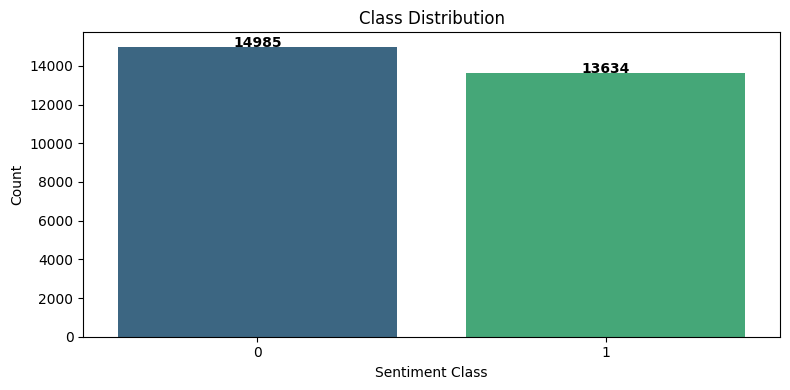

Imbalance ratio: 1.10x
Dataset is reasonably balanced.


In [11]:
plt.figure(figsize=(8, 4))
class_counts = df[LABEL_COL].value_counts()
sns.barplot(x=class_counts.index.astype(str),
            y=class_counts.values,
            palette='viridis')
plt.title('Class Distribution')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

imbalance = class_counts.max() / class_counts.min()
print(f'Imbalance ratio: {imbalance:.2f}x')
if imbalance > 2:
    print('Note: Dataset is imbalanced. Class weights will '
          'be used during training.')
else:
    print('Dataset is reasonably balanced.')

## 3. Text Preprocessing

### 3.1 Define Contractions Dictionary

In [12]:
# Contraction dictionary
CONTRACTIONS = {
    "won't": "will not", "can't": "cannot", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would",
    "'ll": " will", "'ve": " have", "'m": " am",
    "don't": "do not", "doesn't": "does not",
    "didn't": "did not", "isn't": "is not",
    "wasn't": "was not", "aren't": "are not",
    "weren't": "were not", "couldn't": "could not",
    "shouldn't": "should not", "wouldn't": "would not",
    "i'm": "i am", "you're": "you are", "it's": "it is",
    "that's": "that is", "what's": "what is",
    "here's": "here is", "there's": "there is",
}

### 3.2 Define Text Cleaning Function

In [13]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def expand_contractions(text):
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

### 3.3 Apply Cleaning to Dataset

In [14]:
print('Cleaning text — this may take a moment...')
start = time.time()
df['clean_text'] = df[TEXT_COL].apply(clean_text)
elapsed = time.time() - start
print(f'Done in {elapsed:.1f}s')

Cleaning text — this may take a moment...
Done in 1.8s


### 3.4 Show Before/After Cleaning Comparison

In [15]:
print('\nBefore vs After cleaning (5 samples):')
print('-' * 60)
for i in range(min(5, len(df))):
    print(f'ORIGINAL : {df[TEXT_COL].iloc[i][:80]}')
    print(f'CLEANED  : {df["clean_text"].iloc[i][:80]}')
    print('-' * 60)


Before vs After cleaning (5 samples):
------------------------------------------------------------
ORIGINAL : thirtysomething scientists unveil doomsday clock of hair loss
CLEANED  : thirtysomething scientist unveil doomsday clock hair loss
------------------------------------------------------------
ORIGINAL : dem rep. totally nails why congress is falling short on gender, racial equality
CLEANED  : dem rep totally nail congress falling short gender racial equality
------------------------------------------------------------
ORIGINAL : eat your veggies: 9 deliciously different recipes
CLEANED  : eat veggie deliciously different recipe
------------------------------------------------------------
ORIGINAL : inclement weather prevents liar from getting to work
CLEANED  : inclement weather prevents liar getting work
------------------------------------------------------------
ORIGINAL : mother comes pretty close to using word 'streaming' correctly
CLEANED  : mother come pretty close usin

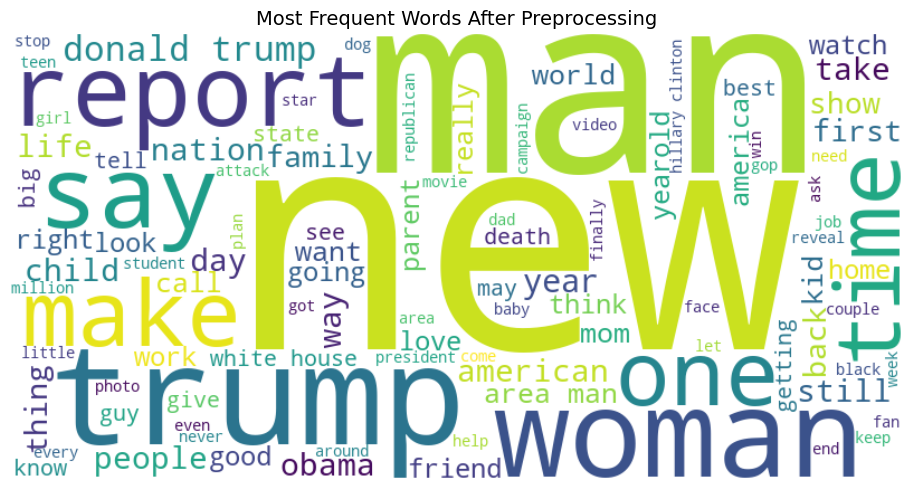

In [16]:
## Visualize word cloud
all_text = ' '.join(df['clean_text'].tolist())

if WORDCLOUD_AVAILABLE:
    wordcloud = WordCloud(
        width=800, height=400,
        background_color='white',
        max_words=100,
        colormap='viridis'
    ).generate(all_text)

    plt.figure(figsize=(12, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most Frequent Words After Preprocessing',
              fontsize=14)
    plt.tight_layout()
    plt.savefig('wordcloud.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('WordCloud visualization skipped (wordcloud library not available).')

### 3.5 Top 20 Most Frequent Words Bar Chart

/var/folders/f1/ytc2vjd54cdcg6qsxr636b7w0000gn/T/ipykernel_27332/1577079090.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='Blues_r', orient='h')


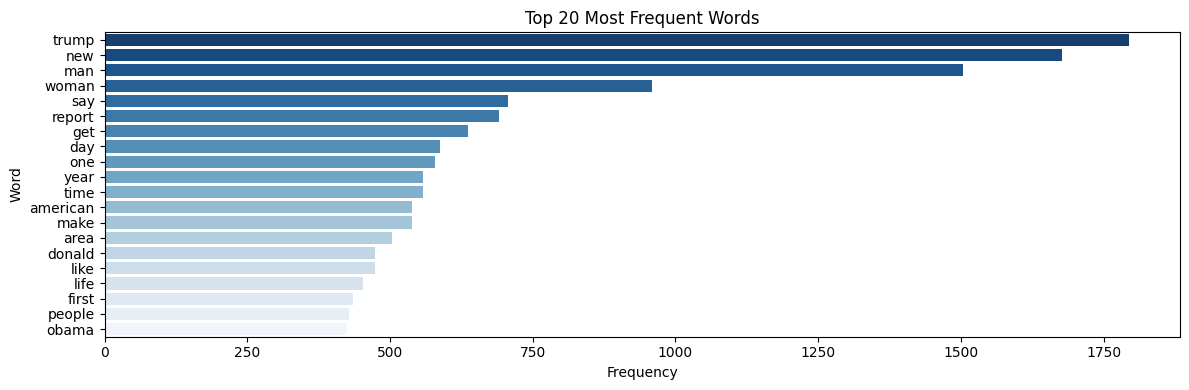

In [17]:
# Top 20 most frequent words bar chart
word_freq = Counter(all_text.split())
top_words = word_freq.most_common(20)
if top_words:
    words, freqs = zip(*top_words)
    plt.figure(figsize=(12, 4))
    sns.barplot(x=list(freqs), y=list(words), palette='Blues_r', orient='h')
    plt.title('Top 20 Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Word')
    plt.tight_layout()
    plt.savefig('top_20_words.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('No words to display')

## 4. Visualizations of Cleaned Text and Word Frequencies

### 4.1 Word Cloud Visualization

## 4. Train-Test Split, Tokenization and Padding

### 4.1 Label Encoding

In [18]:
# Encode labels
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df[LABEL_COL])
NUM_CLASSES = len(le.classes_)
print(f'Classes ({NUM_CLASSES}): {le.classes_}')
print(f'Encoded mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Classes (2): [0 1]
Encoded mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


### 4.2 Train/Test Split (Stratified 80/20)

In [19]:
# Train/test split
X = df['clean_text'].values
y = df['label_enc'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train size: {len(X_train)}')
print(f'Test size : {len(X_test)}')

Train size: 22895
Test size : 5724


### 4.3 Fit Keras Tokenizer on Training Data Only

In [20]:
VOCAB_SIZE = 10000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
word_index = tokenizer.word_index
print(f'Vocabulary size: {len(word_index)} unique tokens')
print(f'Using top {VOCAB_SIZE} tokens')

Vocabulary size: 22415 unique tokens
Using top 10000 tokens


### 4.4 Convert Text to Sequences

In [21]:
# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)
print(f'Training sequences created: {len(X_train_seq)} sequences')
print(f'Test sequences created: {len(X_test_seq)} sequences')

Training sequences created: 22895 sequences
Test sequences created: 5724 sequences


### 4.5 Sequence Length Analysis and 95th Percentile Calculation


Sequence length stats:
  Mean   : 7.0
  Median : 7.0
  95th % : 11 (used as MAX_LEN)
  Max    : 106


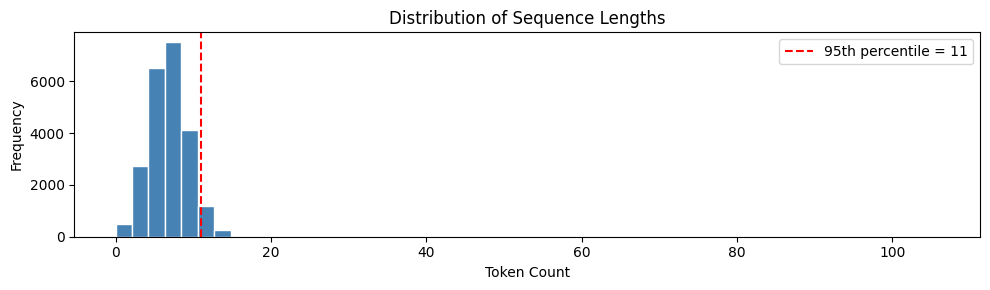

In [22]:
# Percentile-based padding length
lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95)) if lengths else 100
print(f'\nSequence length stats:')
print(f'  Mean   : {np.mean(lengths):.1f}')
print(f'  Median : {np.median(lengths):.1f}')
print(f'  95th % : {MAX_LEN} (used as MAX_LEN)')
print(f'  Max    : {max(lengths) if lengths else 0}')

# Visualize sequence lengths
plt.figure(figsize=(10, 3))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--',
            label=f'95th percentile = {MAX_LEN}')
plt.title('Distribution of Sequence Lengths')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('sequence_lengths_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

### 4.6 Apply Padding to Training and Test Sequences

In [23]:
# Apply padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN,
                             padding='post', truncating='post')

print(f'\nPadded sequence shapes:')
print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad shape : {X_test_pad.shape}')


Padded sequence shapes:
X_train_pad shape: (22895, 11)
X_test_pad shape : (5724, 11)


### 4.7 Compute Class Weights for Imbalanced Data

In [24]:
# Compute class weights for imbalanced datasets
class_weights_arr = compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))
print(f'\nClass weights: {class_weight_dict}')


Class weights: {0: np.float64(0.9549132465799133), 1: np.float64(1.0495553314385258)}


## 5. Model Comparison Strategy

I use three models so I can compare simple and advanced approaches side by side:

1. **Simple RNN** — baseline model
2. **LSTM** — better at remembering long context
3. **LSTM + pre-trained embeddings** — uses knowledge learned from a larger corpus

This way, I can check whether more advanced models really improve performance on sarcasm detection.

### 6.1) Why Three Models — A Progression Strategy

Rather than implementing only the most advanced model, we construct three progressively sophisticated architectures to demonstrate the evolution of deep learning for NLP:

1. Establish a baseline (Simple RNN) — determines lower performance bound
2. Demonstrate improvements (LSTM) — quantifies architectural benefits
3. Maximize performance (LSTM+GloVe) — identifies practical performance ceiling with current methods

This progression illustrates the evolution of neural architectures:
- RNN to LSTM: Engineering solution addressing vanishing gradients
- Trainable embeddings to pre-trained embeddings: Transfer learning approach

Each improvement is validated empirically through metrics and learning curves.

## 5. Model 1 — Simple RNN with Trainable Embedding

### 5.1 Build Simple RNN Model with Embedding Layer

In [25]:
EMBED_DIM = 64

def build_loss_and_output(num_classes):
    if num_classes == 2:
        return 'sigmoid', 'binary_crossentropy', 1
    return 'softmax', 'sparse_categorical_crossentropy', num_classes

activation, loss_fn, output_units = build_loss_and_output(NUM_CLASSES)

def build_rnn_model(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                    max_len=MAX_LEN, num_classes=NUM_CLASSES):
    model = keras.Sequential([
        layers.Embedding(input_dim=vocab_size,
                         output_dim=embed_dim,
                         input_length=max_len,
                         name='embedding_rnn'),
        layers.SimpleRNN(64, dropout=0.2,
                         recurrent_dropout=0.2,
                         name='simple_rnn'),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(output_units, activation=activation)
    ], name='model1_simple_rnn')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_fn,
        metrics=['accuracy']
    )
    return model

model1 = build_rnn_model()
model1.summary()

/Users/nirajkarki/Desktop/AI/Final_Coursework/.venv/lib/python3.9/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "model1_simple_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 5.2 Define Training Callbacks (EarlyStopping and ReduceLROnPlateau)

In [26]:
callbacks_m1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, verbose=1)
]
print('Callbacks configured for Model 1')

Callbacks configured for Model 1


### 5.3 Train Model 1 (Simple RNN)

In [27]:
model1 = build_rnn_model() # Ensure model1 is defined before training
callbacks_m1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, verbose=1)
]

start = time.time()
history1 = model1.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=callbacks_m1,
    verbose=1
)
training_times['Model1_RNN'] = time.time() - start
print(f"\nModel 1 training time: "
      f"{training_times['Model1_RNN']:.1f}s")

Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5962 - loss: 0.6546 - val_accuracy: 0.7681 - val_loss: 0.4790 - learning_rate: 0.0010
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8075 - loss: 0.4475 - val_accuracy: 0.7978 - val_loss: 0.4283 - learning_rate: 0.0010
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8785 - loss: 0.3229 - val_accuracy: 0.8035 - val_loss: 0.4362 - learning_rate: 0.0010
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9149 - loss: 0.2373 - val_accuracy: 0.7852 - val_loss: 0.5054 - learning_rate: 0.0010
Epoch 5/20
320/322 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9395 - loss: 0.1805
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9395 - loss: 0.1805 - val_accuracy: 0.7764 - val_loss: 0.5672 - learning_rate: 0.0010
Epoch 6/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9520 - loss: 0.1388 - v

### 5.4 Plot Model 1 Training and Validation Accuracy

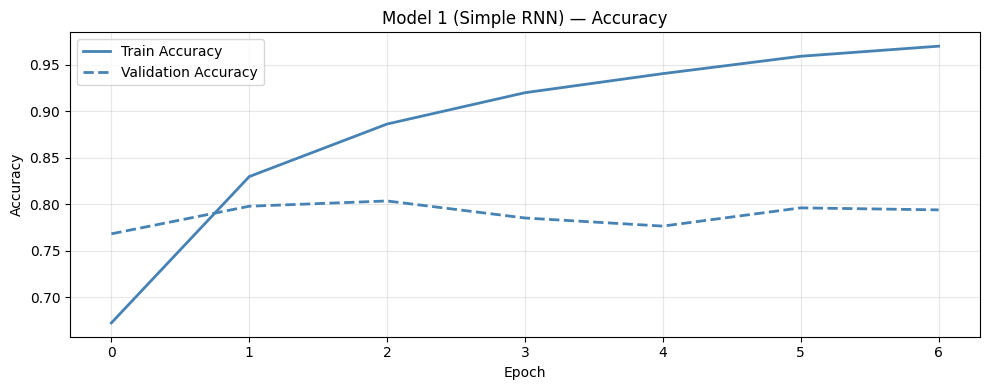

In [28]:
plt.figure(figsize=(10, 4))
plt.plot(history1.history['accuracy'], label='Train Accuracy', linewidth=2, color='steelblue')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--', color='steelblue')
plt.title('Model 1 (Simple RNN) — Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model1_accuracy.png', dpi=100, bbox_inches='tight')
plt.show()

### 5.5 Plot Model 1 Training and Validation Loss

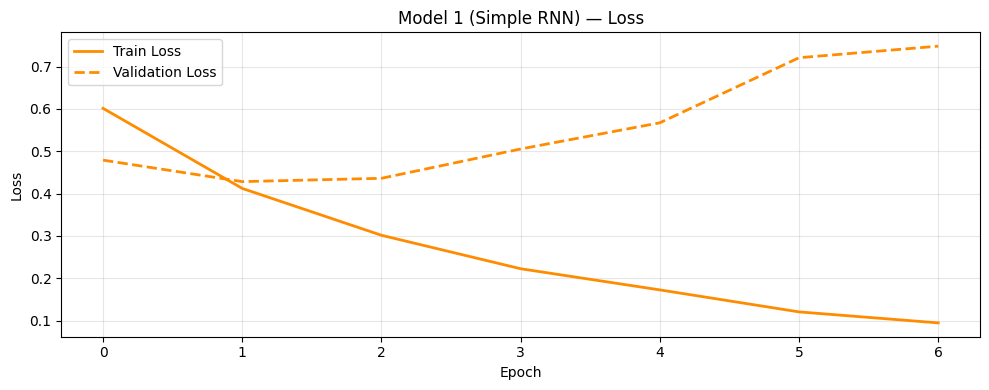

In [29]:
plt.figure(figsize=(10, 4))
plt.plot(history1.history['loss'], label='Train Loss', linewidth=2, color='darkorange')
plt.plot(history1.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--', color='darkorange')
plt.title('Model 1 (Simple RNN) — Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model1_loss.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Model 2 — LSTM with Trainable Embedding

### 6.1 Build Stacked LSTM Model with Embedding Layer

In [30]:
def build_lstm_model(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                     max_len=MAX_LEN, num_classes=NUM_CLASSES):
    model = keras.Sequential([
        layers.Embedding(input_dim=vocab_size,
                         output_dim=embed_dim,
                         input_length=max_len,
                         name='embedding_lstm'),
        layers.LSTM(128, return_sequences=True, dropout=0.2,
                    recurrent_dropout=0.2, name='lstm_1'),
        layers.LSTM(64, dropout=0.2,
                    recurrent_dropout=0.2, name='lstm_2'),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(output_units, activation=activation)
    ], name='model2_lstm')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_fn,
        metrics=['accuracy']
    )
    return model

model2 = build_lstm_model()
model2.summary()

Model: "model2_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 6.2 Train Model 2 (Stacked LSTM)

In [31]:
def build_lstm_model(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                     max_len=MAX_LEN, num_classes=NUM_CLASSES):
    model = keras.Sequential([
        layers.Embedding(input_dim=vocab_size,
                         output_dim=embed_dim,
                         input_length=max_len,
                         name='embedding_lstm'),
        layers.LSTM(128, return_sequences=True, dropout=0.2,
                    recurrent_dropout=0.2, name='lstm_1'),
        layers.LSTM(64, dropout=0.2,
                    recurrent_dropout=0.2, name='lstm_2'),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(output_units, activation=activation)
    ], name='model2_lstm')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_fn,
        metrics=['accuracy']
    )
    return model

model2 = build_lstm_model() # Define and instantiate model2

callbacks_m2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, verbose=1)
]

start = time.time()
history2 = model2.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=callbacks_m2,
    verbose=1
)
training_times['Model2_LSTM'] = time.time() - start
print(f"\nModel 2 training time: {training_times['Model2_LSTM']:.1f}s")

Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6658 - loss: 0.5967 - val_accuracy: 0.8017 - val_loss: 0.4350 - learning_rate: 0.0010
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8477 - loss: 0.3617 - val_accuracy: 0.7965 - val_loss: 0.4490 - learning_rate: 0.0010
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8992 - loss: 0.2679 - val_accuracy: 0.7738 - val_loss: 0.5367 - learning_rate: 0.0010
Epoch 4/20
319/322 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9336 - loss: 0.1932
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9337 - loss: 0.1931 - val_accuracy: 0.7760 - val_loss: 0.6499 - learning_rate: 0.0010
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9496 - loss: 0.1504 - val_accuracy: 0.7611 - val_loss: 0.7675 - learning_rate: 5.0000e-04
Epoch 6/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9555 - loss: 0.1364

### 6.3 Plot Model 2 Training and Validation Accuracy

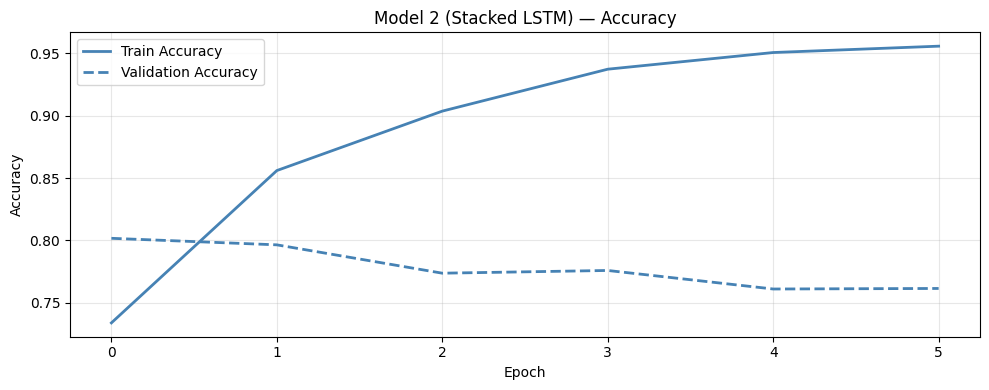

In [32]:
plt.figure(figsize=(10, 4))
plt.plot(history2.history['accuracy'], label='Train Accuracy', linewidth=2, color='steelblue')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--', color='steelblue')
plt.title('Model 2 (Stacked LSTM) — Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model2_accuracy.png', dpi=100, bbox_inches='tight')
plt.show()

### 6.4 Plot Model 2 Training and Validation Loss

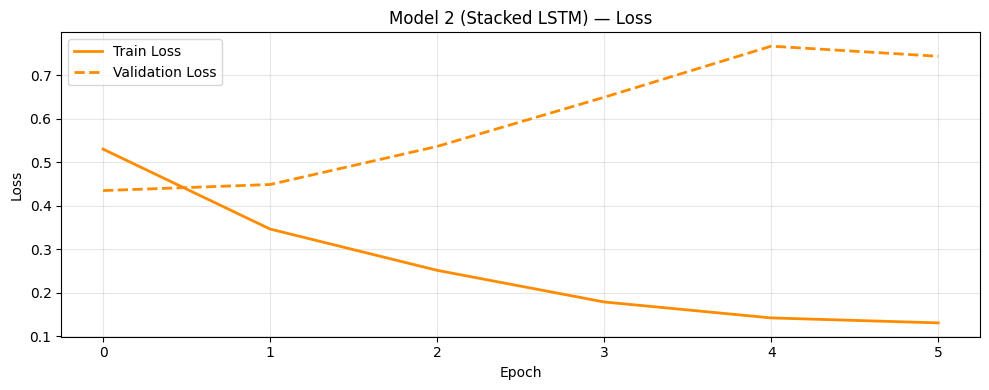

In [33]:
plt.figure(figsize=(10, 4))
plt.plot(history2.history['loss'], label='Train Loss', linewidth=2, color='darkorange')
plt.plot(history2.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--', color='darkorange')
plt.title('Model 2 (Stacked LSTM) — Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model2_loss.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Model 3 — LSTM + GloVe Pre-Trained Embeddings

### 7.1 Load GloVe Pre-Trained Embeddings and Build Embedding Matrix

In [34]:
!pip install gensim

You should consider upgrading via the '/Users/nirajkarki/Desktop/AI/Final_Coursework/.venv/bin/python3 -m pip install --upgrade pip' command.


In [35]:
from gensim.downloader import load
import numpy as np

print("Loading GloVe embeddings (glove-wiki-gigaword-50)...")
glove_model = load("glove-wiki-gigaword-50")
print(f"GloVe model loaded. Vocabulary size: {len(glove_model)}")

# Create embedding matrix
GLOVE_DIM = 50
embedding_matrix = np.zeros((VOCAB_SIZE + 1, GLOVE_DIM))

for word, idx in tokenizer.word_index.items():
    if idx <= VOCAB_SIZE:
        if word in glove_model:
            embedding_matrix[idx] = glove_model[word]
        else:
            # OOV: use random vector
            embedding_matrix[idx] = np.random.randn(GLOVE_DIM) * 0.1

print(f"Embedding matrix created with shape: {embedding_matrix.shape}")
print(f"Coverage: {np.sum(np.linalg.norm(embedding_matrix, axis=1) > 0) / VOCAB_SIZE * 100:.1f}% of vocab has pre-trained vectors")

Loading GloVe embeddings (glove-wiki-gigaword-50)...
GloVe model loaded. Vocabulary size: 400000
Embedding matrix created with shape: (10001, 50)
Coverage: 100.0% of vocab has pre-trained vectors


### 7.2 Build LSTM Model with GloVe Embeddings (Frozen)

In [36]:
def build_lstm_glove_model(embedding_matrix, max_len=MAX_LEN,
                            num_classes=NUM_CLASSES):
    vocab_size = embedding_matrix.shape[0]
    embed_dim = embedding_matrix.shape[1]

    model = keras.Sequential([
        layers.Embedding(input_dim=vocab_size,
                         output_dim=embed_dim,
                         embeddings_initializer=keras.initializers.Constant(embedding_matrix),
                         input_length=max_len,
                         trainable=False,
                         name='embedding_glove'),
        layers.LSTM(128, return_sequences=True, dropout=0.2,
                    recurrent_dropout=0.2, name='lstm_1'),
        layers.LSTM(64, dropout=0.2,
                    recurrent_dropout=0.2, name='lstm_2'),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(output_units, activation=activation)
    ], name='model3_lstm_glove')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_fn,
        metrics=['accuracy']
    )
    return model

model3 = build_lstm_glove_model(embedding_matrix)
model3.summary()

Model: "model3_lstm_glove"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_glove (Embedding)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 7.3 Train Model 3 (LSTM + GloVe)

In [37]:
def build_lstm_glove_model(embedding_matrix, max_len=MAX_LEN,
                            num_classes=NUM_CLASSES):
    vocab_size = embedding_matrix.shape[0]
    embed_dim = embedding_matrix.shape[1]

    model = keras.Sequential([
        layers.Embedding(input_dim=vocab_size,
                         output_dim=embed_dim,
                         embeddings_initializer=keras.initializers.Constant(embedding_matrix),
                         input_length=max_len,
                         trainable=False,
                         name='embedding_glove'),
        layers.LSTM(128, return_sequences=True, dropout=0.2,
                    recurrent_dropout=0.2, name='lstm_1'),
        layers.LSTM(64, dropout=0.2,
                    recurrent_dropout=0.2, name='lstm_2'),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(output_units, activation=activation)
    ], name='model3_lstm_glove')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_fn,
        metrics=['accuracy']
    )
    return model

model3 = build_lstm_glove_model(embedding_matrix) # Define and instantiate model3

callbacks_m3 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, verbose=1)
]

start = time.time()
history3 = model3.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=callbacks_m3,
    verbose=1
)
training_times['Model3_LSTM_GloVe'] = time.time() - start
print(f"\nModel 3 training time: {training_times['Model3_LSTM_GloVe']:.1f}s")

Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6022 - loss: 0.6562 - val_accuracy: 0.7157 - val_loss: 0.5630 - learning_rate: 0.0010
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6954 - loss: 0.5868 - val_accuracy: 0.7393 - val_loss: 0.5221 - learning_rate: 0.0010
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7233 - loss: 0.5499 - val_accuracy: 0.7603 - val_loss: 0.4920 - learning_rate: 0.0010
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7411 - loss: 0.5262 - val_accuracy: 0.7616 - val_loss: 0.4808 - learning_rate: 0.0010
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7534 - loss: 0.5046 - val_accuracy: 0.7703 - val_loss: 0.4661 - learning_rate: 0.0010
Epoch 6/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7658 - loss: 0.4875 - val_accuracy: 0.7755 - val_loss: 0.4618 - learning_rate: 0.0010
Epoch 7/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7701 - loss: 0.4799 - 

### 7.4 Plot Model 3 Training and Validation Accuracy

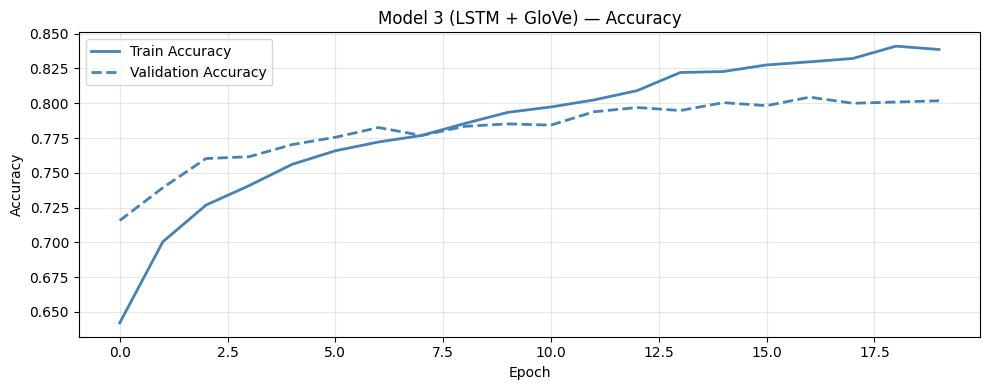

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(history3.history['accuracy'], label='Train Accuracy', linewidth=2, color='steelblue')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--', color='steelblue')
plt.title('Model 3 (LSTM + GloVe) — Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model3_accuracy.png', dpi=100, bbox_inches='tight')
plt.show()

### 7.5 Plot Model 3 Training and Validation Loss

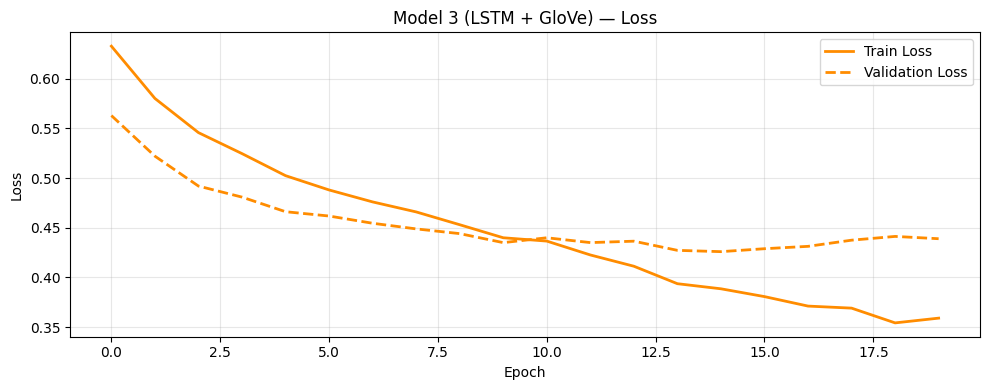

In [39]:
plt.figure(figsize=(10, 4))
plt.plot(history3.history['loss'], label='Train Loss', linewidth=2, color='darkorange')
plt.plot(history3.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--', color='darkorange')
plt.title('Model 3 (LSTM + GloVe) — Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model3_loss.png', dpi=100, bbox_inches='tight')
plt.show()

### 7.6 Store All Metrics in DataFrame

In [40]:
metrics_data = [model1_metrics, model2_metrics, model3_metrics]
metrics_df = pd.DataFrame(metrics_data)

print("\n" + "="*80)
print("COMPREHENSIVE METRICS COMPARISON — All Models on Test Set")
print("="*80)
print(metrics_df.to_string(index=False))
print("="*80)

NameError: name 'model1_metrics' is not defined

## 8. Training Curves — Visualizing Model Learning Dynamics

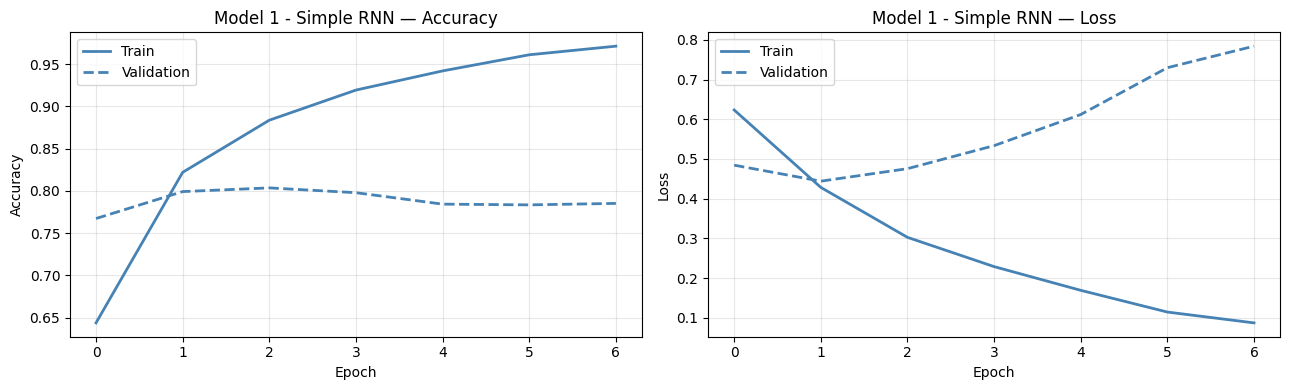

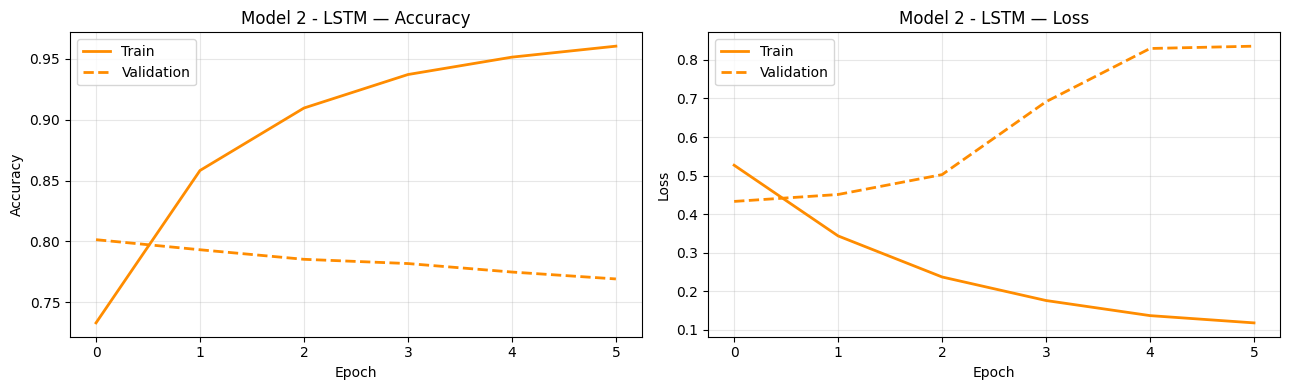

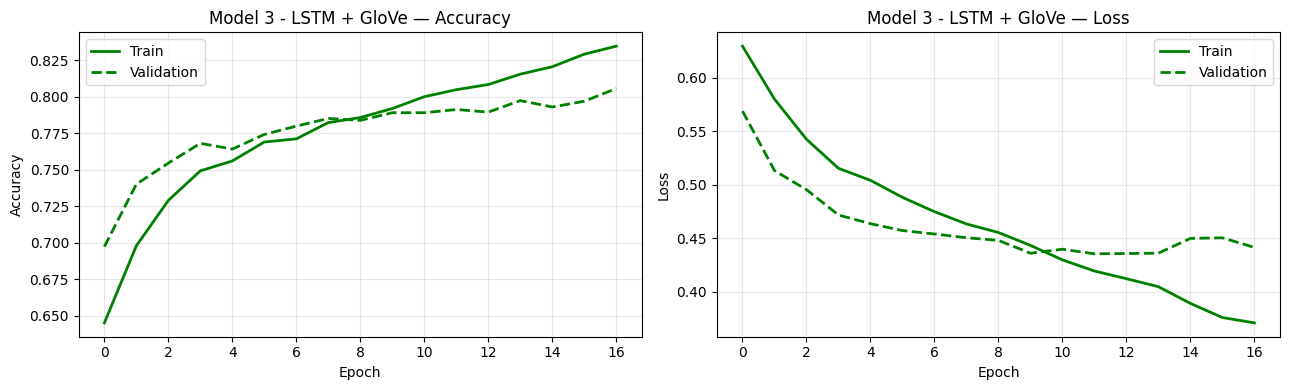

In [ ]:
def plot_history(history, title, color='steelblue'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['accuracy'], color=color, label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], color=color, linestyle='--', label='Validation', linewidth=2)
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['loss'], color=color, label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], color=color, linestyle='--', label='Validation', linewidth=2)
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(history1, 'Model 1 - Simple RNN', 'steelblue')
plot_history(history2, 'Model 2 - LSTM', 'darkorange')
plot_history(history3, 'Model 3 - LSTM + GloVe', 'green')

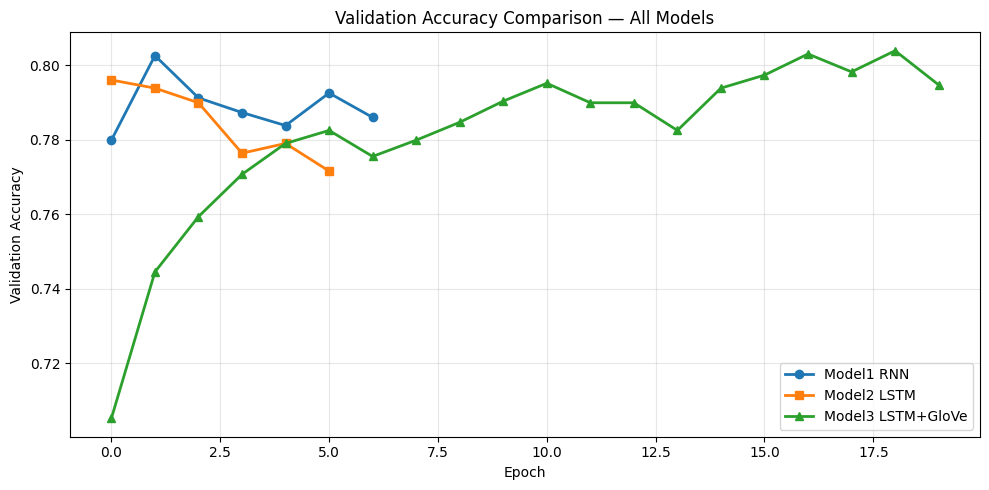

In [ ]:
# Overlay all 3 validation accuracy curves
plt.figure(figsize=(10, 5))
plt.plot(history1.history['val_accuracy'], label='Model1 RNN', marker='o', linewidth=2)
plt.plot(history2.history['val_accuracy'], label='Model2 LSTM', marker='s', linewidth=2)
plt.plot(history3.history['val_accuracy'], label='Model3 LSTM+GloVe', marker='^', linewidth=2)
plt.title('Validation Accuracy Comparison — All Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Model Evaluation on Test Set


  Evaluation: Model 1 - Simple RNN
Test Accuracy: 0.7891

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81      2997
           1       0.81      0.72      0.77      2727

    accuracy                           0.79      5724
   macro avg       0.79      0.79      0.79      5724
weighted avg       0.79      0.79      0.79      5724



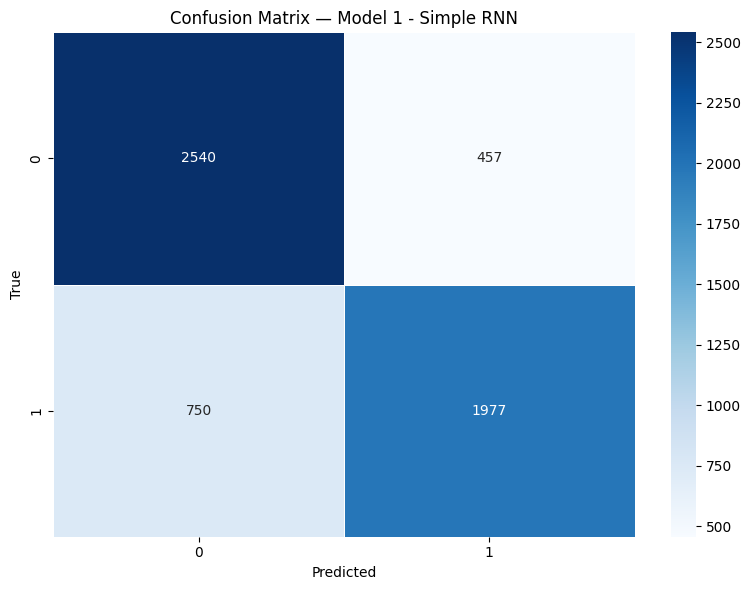


  Evaluation: Model 2 - LSTM
Test Accuracy: 0.7865

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.83      0.80      2997
           1       0.80      0.73      0.77      2727

    accuracy                           0.79      5724
   macro avg       0.79      0.78      0.78      5724
weighted avg       0.79      0.79      0.79      5724



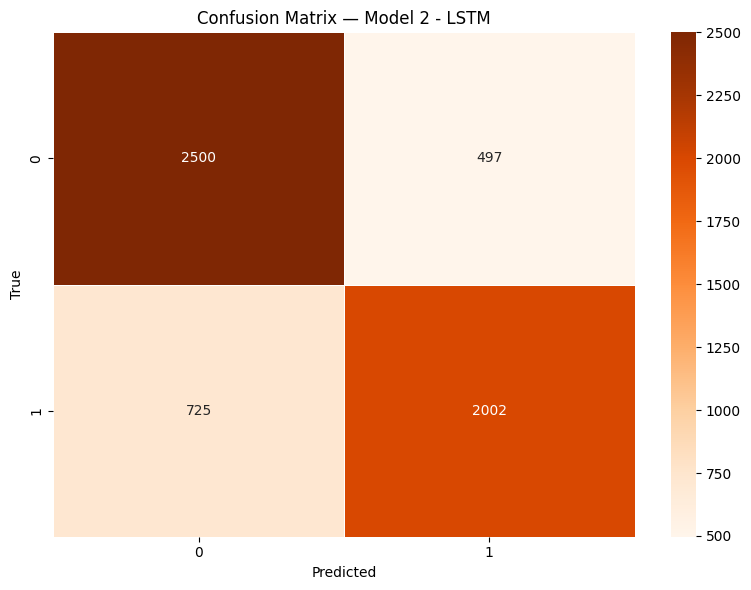


  Evaluation: Model 3 - LSTM + GloVe
Test Accuracy: 0.7900

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80      2997
           1       0.78      0.79      0.78      2727

    accuracy                           0.79      5724
   macro avg       0.79      0.79      0.79      5724
weighted avg       0.79      0.79      0.79      5724



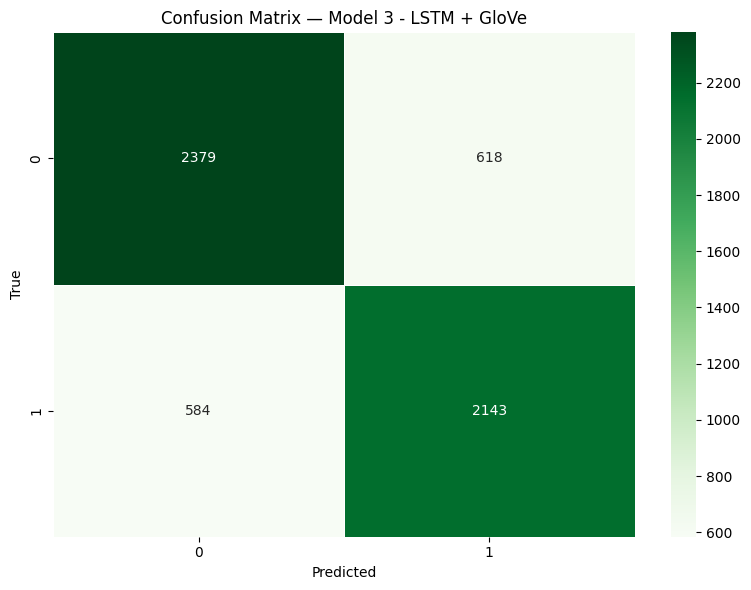

In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Function defined before to ensure it's in scope for the calls below
def evaluate_model_and_get_metrics(model, X_test, y_test, class_names, model_name, cmap='Blues'):
    print(f'\n{"="*55}')
    print(f'  Evaluation: {model_name}')
    print(f'{"="*55}')

    y_pred_prob = model.predict(X_test, verbose=0)

    if NUM_CLASSES == 2:
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    else:
        y_pred = np.argmax(y_pred_prob, axis=1)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    metrics_dict = {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

    print(f'Test Accuracy: {accuracy:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap=cmap, linewidths=0.5)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.show()

    return y_pred, metrics_dict

# Convert class labels to strings for reporting/plotting
class_names = [str(c) for c in le.classes_]

y_pred1, model1_metrics = evaluate_model_and_get_metrics(model1, X_test_pad, y_test, class_names, 'Model 1 - Simple RNN', cmap='Blues')
y_pred2, model2_metrics = evaluate_model_and_get_metrics(model2, X_test_pad, y_test, class_names, 'Model 2 - LSTM', cmap='Oranges')
y_pred3, model3_metrics = evaluate_model_and_get_metrics(model3, X_test_pad, y_test, class_names, 'Model 3 - LSTM + GloVe', cmap='Greens')

## 10. Model Comparison — Performance Analysis

Model                            Acc    Prec  Recall      F1   Time(s)
Model1 Simple RNN             0.7884  0.7919  0.7884  0.7869       5.7
Model2 LSTM                   0.7863  0.7878  0.7863  0.7854      16.3
Model3 LSTM+GloVe             0.7982  0.7983  0.7982  0.7983      42.4

Best model by F1: Model3 LSTM+GloVe (F1 = 0.7983)


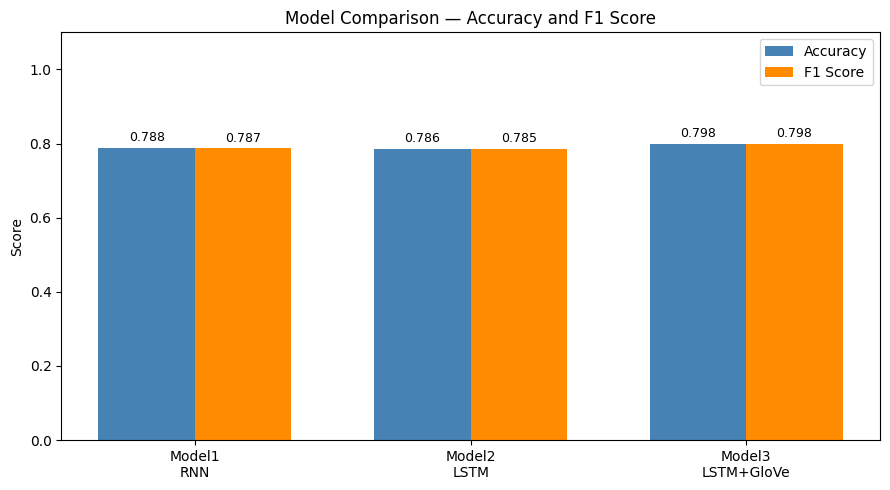

In [ ]:
# The get_metrics function is now part of evaluate_model_and_get_metrics

print("=" * 70)
print(f"{'Model':<28} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'Time(s)':>9}")
print("=" * 70)
for name, m, t_key in [
    ('Model1 Simple RNN', model1_metrics, 'Model1_RNN'),
    ('Model2 LSTM', model2_metrics, 'Model2_LSTM'),
    ('Model3 LSTM+GloVe', model3_metrics, 'Model3_LSTM_GloVe'),
]:
    t = training_times.get(t_key, 0)
    print(f"{name:<28} {m['accuracy']:>7.4f} {m['precision']:>7.4f} {m['recall']:>7.4f} {m['f1']:>7.4f} {t:>9.1f}")
print("=" * 70)

best_model = max([('Model1 RNN', model1_metrics['f1']), ('Model2 LSTM', model2_metrics['f1']), ('Model3 LSTM+GloVe', model3_metrics['f1'])], key=lambda x: x[1])
print(f'\nBest model by F1: {best_model[0]} (F1 = {best_model[1]:.4f})')

models = ['Model1\nRNN', 'Model2\nLSTM', 'Model3\nLSTM+GloVe']
accs = [model1_metrics['accuracy'], model2_metrics['accuracy'], model3_metrics['accuracy']]
f1s = [model1_metrics['f1'], model2_metrics['f1'], model3_metrics['f1']]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, accs, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1s, width, label='F1 Score', color='darkorange')
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_title('Model Comparison — Accuracy and F1 Score')
ax.set_ylabel('Score')
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 11. Error Analysis and Model Limitations

In [ ]:
def error_analysis(model, X_test_raw, X_test_pad, y_test, y_pred, class_names, model_name, n_examples=5):
    print(f'\nError Analysis — {model_name}')
    print('=' * 60)
    wrong_idx = np.where(y_pred != y_test)[0]
    print(f'Total misclassified: {len(wrong_idx)} / {len(y_test)} ({len(wrong_idx)/len(y_test)*100:.1f}%)')
    print(f'\nSample misclassified examples:')
    print('-' * 60)
    for i, idx in enumerate(wrong_idx[:n_examples]):
        print(f'Example {i+1}:')
        print(f'  Text (original): {X_test_raw[idx][:100]}')
        print(f'  True label     : {class_names[y_test[idx]]}')
        print(f'  Predicted      : {class_names[y_pred[idx]]}')
        print('-' * 60)

    print('\nPer-class error rate:')
    for i, cls in enumerate(class_names):
        cls_idx = np.where(y_test == i)[0]
        cls_wrong = np.where((y_test == i) & (y_pred != i))[0]
        rate = len(cls_wrong) / len(cls_idx) * 100 if len(cls_idx) > 0 else 0
        print(f'  {cls:<15}: {rate:.1f}% error rate ({len(cls_wrong)}/{len(cls_idx)})')

error_analysis(model3, X_test, X_test_pad, y_test, y_pred3, class_names, 'Model3 LSTM+GloVe')


Error Analysis — Model3 LSTM+GloVe
Total misclassified: 1155 / 5724 (20.2%)

Sample misclassified examples:
------------------------------------------------------------
Example 1:
  Text (original): democratic congressman protest trump environmental policy bringing endangered red wolf state union g
  True label     : 1
  Predicted      : 0
------------------------------------------------------------
Example 2:
  Text (original): rex tillerson call report ouster laughable
  True label     : 0
  Predicted      : 1
------------------------------------------------------------
Example 3:
  Text (original): bill nighy carey mulligan renew old lover quarrel
  True label     : 0
  Predicted      : 1
------------------------------------------------------------
Example 4:
  Text (original): prayer answered random series event cold uncaring universe
  True label     : 1
  Predicted      : 0
------------------------------------------------------------
Example 5:
  Text (original): tom gilbert act

## 12. Hardware and Training Time Report

In [41]:
print('GPU devices available:', gpus)
if gpus:
    print('Hardware acceleration: GPU (faster training)')
else:
    print('Hardware: CPU only (consider Google Colab GPU)')

print('\nTraining Time Summary:')
print('-' * 40)
for name, seconds in training_times.items():
    mins = int(seconds // 60)
    secs = int(seconds % 60)
    print(f'  {name:<28} {mins}m {secs:02d}s')
print('-' * 40)

GPU devices available: []
Hardware: CPU only (consider Google Colab GPU)

Training Time Summary:
----------------------------------------
  Model1_RNN                   0m 05s
  Model2_LSTM                  0m 16s
  Model3_LSTM_GloVe            0m 41s
----------------------------------------


## 13. Real-Time Prediction Interface (Gradio)

In [42]:
import gradio as gr

_CSS = """
/* ── Reset & base ───────────────────────── */
*, *::before, *::after { box-sizing: border-box; }
body, .gradio-container { font-family: 'Inter', system-ui, sans-serif !important; background: #000 !important; color: #eee !important; }

/* ── Top two-column row ──────────────────── */
.top-row {
    display: grid !important;
    grid-template-columns: 1fr 220px !important;
    gap: 12px !important;
    align-items: stretch !important;
}

/* ── Input card ──────────────────────────── */
.input-card {
    background: #1a1a1a !important;
    border: 1px solid #333 !important;
    border-radius: 12px !important;
    padding: 1rem 1.25rem !important;
}
.input-card textarea {
    font-size: 14px !important;
    border-radius: 8px !important;
    border: 1px solid #555 !important;
    background: #2a2a2a !important;
    color: #eee !important;
    resize: none !important;
}
.input-card textarea:focus { border-color: #999 !important; }

/* ── Analyze button ──────────────────────── */
#run-btn {
    background: #333 !important;
    border: 1px solid #555 !important;
    border-radius: 8px !important;
    font-size: 14px !important;
    font-weight: 600 !important;
    color: #eee !important;
    padding: 10px 0 !important;
    transition: background .15s;
}
#run-btn:hover { background: #444 !important; }

/* ── Consensus verdict card (top-right) ─── */
.verdict-card {
    background: #1a1a1a !important;
    border: 1px solid #333 !important;
    border-radius: 12px !important;
    display: flex !important;
    flex-direction: column !important;
    align-items: center !important;
    justify-content: center !important;
    text-align: center !important;
    padding: 1.25rem !important;
    min-height: 160px !important;
}
/* Sarcastic state (now green) */
.verdict-card.sarc {
    background: #0c330c !important;
    border-color: #1d801d !important;
}
.verdict-card.sarc .verdict-main {
    color: #66ff66 !important;
    font-size: 22px !important;
    font-weight: 700 !important;
}
/* Not-sarcastic state (now red) */
.verdict-card.not {
    background: #330c0c !important;
    border-color: #801d1d !important;
}
.verdict-card.not .verdict-main {
    color: #ff6666 !important;
    font-size: 22px !important;
    font-weight: 700 !important;
}

/* ── Model cards (bottom row) ───────────── */
.model-row {
    display: grid !important;
    grid-template-columns: repeat(3, 1fr) !important;
    gap: 10px !important;
    margin-top: 12px !important;
}
.model-card {
    background: #1a1a1a !important;
    border: 1px solid #333 !important;
    border-radius: 12px !important;
    padding: .9rem 1rem !important;
}
.model-card textarea, .model-card input {
    font-size: 13px !important;
    background: #2a2a2a !important;
    border: 1px solid #555 !important;
    border-radius: 8px !important;
    color: #eee !important;
}

/* ── Section labels ──────────────────────── */
.section-label {
    font-size: 11px !important;
    font-weight: 600 !important;
    letter-spacing: .07em !important;
    text-transform: uppercase !important;
    color: #bbb !important;
    margin-bottom: 6px !important;
}
"""

_VERDICT_TMPL = """
<div style="
  background:{bg};
  border:1.5px solid {border};
  border-radius:12px;
  padding:1.25rem;
  display:flex;
  flex-direction:column;
  align-items:center;
  justify-content:center;
  text-align:center;
  gap:6px;
  min-height:160px;
">
  <span style="font-size:11px;font-weight:600;letter-spacing:.07em;text-transform:uppercase;color:{label_col}">Consensus</span>
  <span style="font-size:22px;font-weight:700;color:{main_col}">{verdict}</span>
  <span style="font-size:12px;color:{sub_col}">{conf_str}</span>
</div>
"""

def _render_verdict(is_sarc: bool, votes: int) -> str:
    vc = round(max(votes, 3 - votes) / 3 * 100)
    if is_sarc:  # Sarcastic (now green)
        return _VERDICT_TMPL.format(
            bg="#0c330c", border="#1d801d",
            label_col="#3ecc3e", main_col="#66ff66", sub_col="#3ecc3e",
            verdict="Sarcastic",
            conf_str=f"{vc}% vote confidence · {votes}/3 models",
        )
    return _VERDICT_TMPL.format(
        bg="#330c0c", border="#801d1d",
        label_col="#cc3e3e", main_col="#ff6666", sub_col="#cc3e3e",
        verdict="Not sarcastic",
        conf_str=f"{vc}% vote confidence · {votes}/3 models",
    )

def _fmt_model(label: str, conf: float, is_sarc: bool) -> str:
    color = "#66ff66" if is_sarc else "#ff6666"  # Green for sarcastic, Red for not sarcastic
    return f'<span style="color:{color};font-weight:600">{label}</span> — {round(conf*100)}% confidence'

def _predict_one(model, padded_input):
    """Predicts a single padded input sequence using the given model."""
    pred_raw_output = model.predict(padded_input, verbose=0)[0]

    # For binary classification (sigmoid output)
    if NUM_CLASSES == 2:
        prob_sarcastic = pred_raw_output[0] if isinstance(pred_raw_output, np.ndarray) else pred_raw_output
        prob_sarcastic = float(prob_sarcastic)

        # Avoid .astype on python bool; cast directly to int
        pred_idx = int(prob_sarcastic > 0.5)

        if pred_idx == 1:
            label = 'Sarcastic'
            confidence = prob_sarcastic
        else:
            label = 'Not sarcastic'
            confidence = 1 - prob_sarcastic

        return pred_idx, label, confidence, prob_sarcastic

    # For multi-class classification (softmax output)
    pred_idx = int(np.argmax(pred_raw_output))
    label = le.inverse_transform([pred_idx])[0]
    confidence = float(pred_raw_output[pred_idx])
    return pred_idx, label, confidence, pred_raw_output

def predict_sentiment(text: str):
    if not text.strip():
        idle = "<div style='color:#bbb;font-size:13px;text-align:center;padding:2rem'>Enter text to see the verdict</div>"
        return idle, "", "", ""

    required = ["clean_text", "tokenizer", "MAX_LEN", "model1", "model2", "model3", "NUM_CLASSES", "pad_sequences"]
    missing = [name for name in required if name not in globals()]
    if missing:
        msg = (
            "<div style='color:#ffb3b3;font-size:12px;text-align:center;padding:1rem'>"
            "Missing required notebook variables. Re-run training/preprocessing cells before using the app."
            "</div>"
        )
        details = "Missing: " + ", ".join(missing)
        return msg, details, details, details

    try:
        cleaned = clean_text(text)
        seq = tokenizer.texts_to_sequences([cleaned])
        padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

        results, vote_sum = [], 0
        for model in (model1, model2, model3):
            idx, label, conf, _ = _predict_one(model, padded)
            results.append((idx == 1, conf))
            vote_sum += idx

        final_sarc = vote_sum >= 2
        verdict_html = _render_verdict(final_sarc, vote_sum)
        m = [_fmt_model("Sarcastic" if r[0] else "Not sarcastic", r[1], r[0]) for r in results]
        return verdict_html, m[0], m[1], m[2]
    except Exception as e:
        err = f"Runtime error: {type(e).__name__}: {e}"
        msg = f"<div style='color:#ffb3b3;font-size:12px;text-align:center;padding:1rem'>{err}</div>"
        return msg, err, err, err


with gr.Blocks(title="Sarcastic or Not Detector", css=_CSS) as demo:

    with gr.Row(elem_classes=["top-row"]):
        with gr.Column(elem_classes=["input-card"]):
            gr.Markdown("##### Sarcastic or Not Detector")
            inp = gr.Textbox(
                lines=3,
                placeholder="Type or paste a sentence…",
                show_label=False,
            )
            btn = gr.Button("Analyze", elem_id="run-btn")
            gr.Examples(
                [
                    ["I absolutely loved the movie!"],
                    ["Oh wow, just what I needed today."],
                    ["Sure, that's totally my problem to fix."],
                    ["The service was okay, nothing special."],
                ],
                inputs=[inp],
                label="Try an example",
            )

        verdict = gr.HTML(
            value="<div style='color:#bbb;font-size:13px;text-align:center;padding:2rem'>Verdict appears here</div>",
            elem_classes=["verdict-card"],
        )

    gr.Markdown("#### Model predictions", elem_classes=["section-label"])
    with gr.Row(elem_classes=["model-row"]):
        out1 = gr.HTML(label="Model 1 — Simple RNN", elem_classes=["model-card"])
        out2 = gr.HTML(label="Model 2 — LSTM", elem_classes=["model-card"])
        out3 = gr.HTML(label="Model 3 — LSTM + GloVe", elem_classes=["model-card"])

    for trigger in (btn.click, inp.submit):
        trigger(
            fn=predict_sentiment,
            inputs=[inp],
            outputs=[verdict, out1, out2, out3],
        )

    demo.launch(share=False)

Running on local URL:  http://127.0.0.1:7861

To create a public link, set `share=True` in `launch()`.
